# Yield Curve Module 3: IRRBB -- OIS Curve Application

## 1. EBA IRRBB Stress Scenarios

Six prescribed rate shocks from EBA/GL/2022/14 applied to the ESTR OIS
discount curve bootstrapped in Notebook 2. The OIS curve is the regulatory
prescribed input for IRRBB EVE calculations under EBA/RTS/2022/09.

This notebook covers four components of the IRRBB framework:
1. EVE Supervisory Outlier Test -- six scenarios, 15% Tier 1 threshold
2. NII Supervisory Outlier Test -- parallel up/down, 5% Tier 1 threshold
3. Repricing gap -- cash flows bucketed into EBA maturity bands
4. SA vs full revaluation comparison

The six shock scenarios are:
- **Parallel up / down** -- uniform shift across all maturities
- **Steepener** -- short rates down, long rates up
- **Flattener** -- short rates up, long rates down
- **Short rate up / down** -- shock concentrated at the short end,
  fading linearly to zero at 20Y

#### EBA/RTS/2022/10 Annex I -- Prescribed IRRBB Shock Sizes (bps)

Source: EBA/RTS/2022/10, Annex I, October 2022.
These are regulatory inputs, not model calibrations.

 Currency | Parallel | Short | Long 
----------|----------|-------|------
 EUR      | 200      | 250   | 100  
 USD      | 200      | 300   | 150  
 JPY      | 100      | 100   | 100  
 BRL      | 400      | 500   | 300  
 GBP      | 250      | 300   | 150  
 CHF      | 100      | 150   | 100  

**EBA Methodology:** To arrive in these values, EBA calibrated schocks to the 99th percentile of rolling
6-month interest rate changes over 2000-2015. A floor of 100bps applies to
all currencies regardless of historical data. Caps are 400bps parallel,
500bps short, 300bps long.

**BRL note:** BRL is not an EBA-regulated currency -- it is included in the
Basel BCBS standard which uses the same methodology. A Luxembourg bank with
material BRL positions would apply these shocks under Pillar 2 ICAAP
at its own discretion, not as a mandatory EBA SOT.

**JPY note:** The 100bps flat shock across all tenors reflects the prolonged
near-zero rate environment in Japan. Post-2022 BoJ policy normalisation
has reopened debate on whether this remains appropriate -- the BCBS
recalibration exercise (d561, 2023) flagged this as a currency where
the current shocks may need upward revision.

**How the six scenarios are derived from these three shock sizes:**

Let $S_{parallel}$, $S_{short}$, $S_{long}$ denote the prescribed shock sizes
from the table above for a given currency. Then:

$$\Delta R_{parallel} = \pm S_{parallel}$$

$$\Delta R_{steepener} = -0.65 \cdot S_{short} + 0.9 \cdot S_{long}$$

$$\Delta R_{flattener} = +0.8 \cdot S_{short} - 0.6 \cdot S_{long}$$

$$\Delta R_{short\_up} = +S_{short} \text{ (fading linearly to zero at 20Y+)}$$

$$\Delta R_{short\_down} = -S_{short} \text{ (fading linearly to zero at 20Y+)}$$

#### Post-Shock Interest Rate Floor

EBA/RTS/2022/10 Article 4 imposes a maturity-dependent lower bound on
post-shock rates:

$$floor(T) = -150\text{bps} + 3\text{bps} \times T$$

The floor reflects the empirical lower bound on nominal interest rates --
the effective lower bound (ELB) below which monetary transmission breaks
down and cash hoarding becomes rational. It is not symmetric: only downward
shock scenarios can breach it, upward scenarios are unconstrained.

The slope of 3bps per year embeds the term premium -- longer maturities
can sustain slightly less negative rates because the compensation for
duration risk provides a natural floor. At key maturities:

| Maturity | Floor |
|----------|-------|
| 0Y       | -150bps |
| 10Y      | -120bps |
| 20Y      | -90bps  |
| 30Y      | -60bps  |

For EUR the floor is rarely binding post-2022 given the ECB has exited
negative rate territory and current short rates sit above 2%. For JPY
the floor is material -- with the BoJ only beginning normalisation in
2024, a -100bps parallel down shock on a curve starting near zero
immediately breaches the floor across the short and medium end.

The floor also has a practical implication for EVE: when the floor clips
a downward scenario, the actual EVE impact is smaller than the unclipped
version. The EBA requires institutions to report both the clipped
(regulatory) and unclipped (unconstrained) parallel down scenario
precisely to make this effect transparent to supervisors.

#### Data

OIS zero curve bootstrapped in Notebook 2, loaded from `data/processed/`.
All EVE calculations use OIS discounting as prescribed by EBA/RTS/2022/09.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-v0_8-whitegrid")

# -----------------------------------------------------------------------
# load OIS curve from data/processed
# -----------------------------------------------------------------------
project_root  = os.path.abspath(os.path.join(os.getcwd(), "../.."))
processed_dir = os.path.join(project_root, "data", "processed")

# find the most recent OIS curve file
ois_files = sorted([f for f in os.listdir(processed_dir) if f.startswith("ois_curve_")])
if not ois_files:
    raise FileNotFoundError("No OIS curve file found in data/processed. Run notebook 2 first.")

ois_file = os.path.join(processed_dir, ois_files[-1])
ois_data = pd.read_csv(ois_file, index_col="maturity")

valuation_date = ois_data["valuation_date"].iloc[0]
print(f"OIS curve loaded: {ois_file}")
print(f"Valuation date  : {valuation_date}")
print(f"\n{ois_data}")

OIS curve loaded: /Users/mrspatbile/Documents/coding/quant-risk-engine/data/processed/ois_curve_2026-03-24.csv
Valuation date  : 2026-03-24

              years  zero_rate_pct  discount_factor valuation_date
maturity                                                          
1M         0.083333       1.938381         0.998332     2026-03-24
2M         0.166667       1.951716         0.996644     2026-03-24
3M         0.250000       1.984957         0.994940     2026-03-24
6M         0.500000       2.062095         0.989516     2026-03-24
9M         0.750000       1.998665         0.984848     2026-03-24
12M        1.000000       2.023108         0.979697     2026-03-24
2Y         2.000000       2.154424         0.957196     2026-03-24
3Y         3.000000       2.208785         0.934851     2026-03-24
5Y         5.000000       2.331640         0.888460     2026-03-24
10Y       10.000000       2.624891         0.766168     2026-03-24
10Y+      15.000000       2.935061         0.639684    

In [23]:
# EBA/RTS/2022/10 Annex I -- prescribed shock sizes in bps by currency
EBA_SHOCKS = {
    "EUR": {"parallel": 200, "short": 250, "long": 100},
    "USD": {"parallel": 200, "short": 300, "long": 150},
    "JPY": {"parallel": 100, "short": 100, "long": 100},
    "BRL": {"parallel": 400, "short": 500, "long": 300},
    "GBP": {"parallel": 250, "short": 300, "long": 150},
    "CHF": {"parallel": 100, "short": 150, "long": 100},
}

def compute_irrbb_scenarios(zero_rates, maturities, currency="EUR"):
    """
    Apply EBA/RTS/2022/10 six IRRBB shock scenarios to a zero rate curve.

    Shock sizes from Annex I. Steepener and flattener formulas from
    Table 1 of the RTS. Short rate shocks fade linearly to zero at 20Y.
    Post-shock floor applied per Article 4: -150bps + 3bps per year.

    Parameters
    ----------
    zero_rates : np.ndarray
        Baseline zero rates in percent.
    maturities : np.ndarray
        Corresponding maturities in years.
    currency : str
        One of EUR, USD, JPY, BRL, GBP, CHF.

    Returns
    -------
    dict of {scenario_name: shocked_zero_rates}
    """
    s = EBA_SHOCKS[currency]
    S_par   = s["parallel"] / 100
    S_short = s["short"]   / 100
    S_long  = s["long"]    / 100

    # weight for short/long interpolation: 0 at T=0, 1 at T=20Y
    w = np.clip(maturities / 20, 0, 1)

    # maturity-dependent shock profiles
    shock_parallel = S_par * np.ones_like(maturities)
    shock_short    = S_short * (1 - w)
    shock_long     = S_long  * w

    # post-shock floor: -150bps + 3bps per year, in percent
    floor = (-150 + 3 * maturities) / 100

    # six scenarios with floor applied
    raw = {
        "parallel_up"   :  zero_rates + shock_parallel,
        "parallel_down" :  zero_rates - shock_parallel,
        "steepener"     :  zero_rates - 0.65 * shock_short + 0.9 * shock_long,
        "flattener"     :  zero_rates + 0.8  * shock_short - 0.6 * shock_long,
        "short_up"      :  zero_rates + shock_short,
        "short_down"    :  zero_rates - shock_short,
    }

    # apply floor -- only downward scenarios can breach it
    scenarios = {
        name: np.maximum(curve, floor)
        for name, curve in raw.items()
    }

    return scenarios

# -----------------------------------------------------------------------
# build baseline from OIS curve loaded from data/processed
# -----------------------------------------------------------------------
T        = np.linspace(1/12, 30, 360)
baseline = np.interp(
    T,
    ois_data["years"].values,
    ois_data["zero_rate_pct"].values
)

scenarios = compute_irrbb_scenarios(baseline, T, currency="EUR")

# print short and long end for each scenario
print(f"Baseline curve: OIS -- valuation date {valuation_date}")
print(f"\n{'Scenario':<20} {'3M rate':>10} {'10Y rate':>10} {'30Y rate':>10}")
print("-" * 55)
print(f"{'Baseline':<20} {baseline[3]:>10.3f} {baseline[120]:>10.3f} {baseline[-1]:>10.3f}")
for name, curve in scenarios.items():
    print(f"{name:<20} {curve[3]:>10.3f} {curve[120]:>10.3f} {curve[-1]:>10.3f}")

Baseline curve: OIS -- valuation date 2026-03-24

Scenario                3M rate   10Y rate   30Y rate
-------------------------------------------------------
Baseline                  2.011      2.630      2.935
parallel_up               4.011      4.630      4.935
parallel_down             0.011      0.630      0.935
steepener                 0.428      2.278      3.835
flattener                 3.967      3.319      2.335
short_up                  4.469      3.870      2.935
short_down               -0.448      1.390      2.935


In [24]:
# check if floor is binding for any EUR scenario
floor = (-150 + 3 * T) / 100

print("Floor binding check -- EUR scenarios:")
for name, curve in scenarios.items():
    n_clipped = np.sum(curve < floor + 1e-6)
    min_rate  = curve.min()
    if n_clipped > 0:
        print(f"  {name:<20} min rate: {min_rate:.3f}%   floor binding at {n_clipped} points")
    else:
        print(f"  {name:<20} min rate: {min_rate:.3f}%   floor not binding")

Floor binding check -- EUR scenarios:
  parallel_up          min rate: 3.938%   floor not binding
  parallel_down        min rate: -0.062%   floor not binding
  steepener            min rate: 0.324%   floor not binding
  flattener            min rate: 2.335%   floor not binding
  short_up             min rate: 2.935%   floor not binding
  short_down           min rate: -0.551%   floor not binding


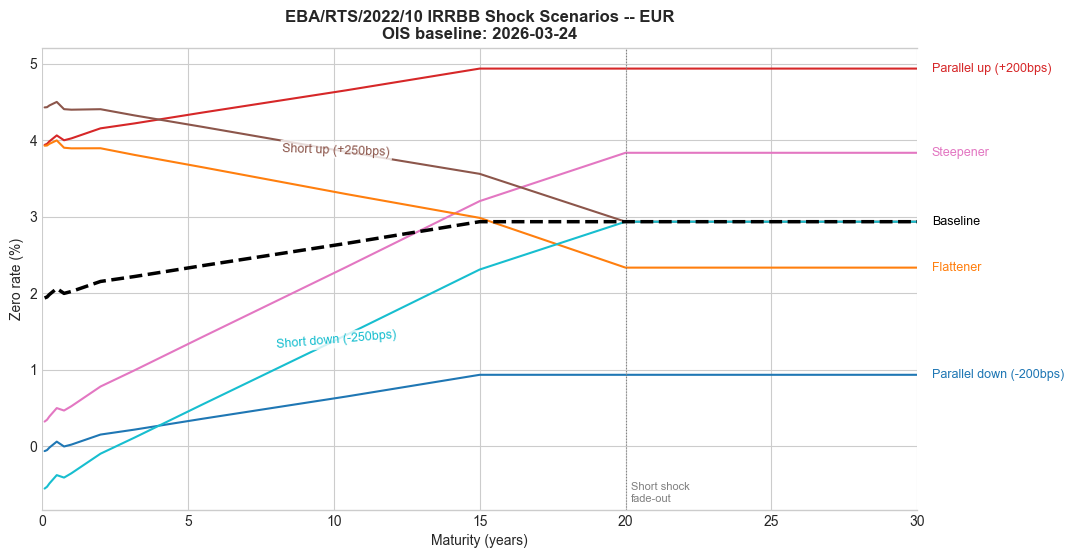

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.set_xlim(0, 30)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


colors = {
    "parallel_up"   : "#d62728",
    "parallel_down" : "#1f77b4",
    "steepener"     : "#e377c2",
    "flattener"     : "#ff7f0e",
    "short_up"      : "#8c564b",
    "short_down"    : "#17becf",
}

end_labels = {
    "parallel_up"   : ("Parallel up (+200bps)",  0.0),
    "parallel_down" : ("Parallel down (-200bps)", 0.0),
    "steepener"     : ("Steepener",               0.0),
    "flattener"     : ("Flattener",               0.0),
}

mid_labels = {
    "short_up"   : ("Short up (+250bps)",   120),
    "short_down" : ("Short down (-250bps)", 120),
}

def line_angle_correct(curve, ax):
    # data ranges
    x_data_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_data_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    
    # axis size in pixels
    bbox = ax.get_window_extent()
    x_pixel_range = bbox.width
    y_pixel_range = bbox.height
    
    # slope in data units
    x1, x2 = T[50], T[200]
    y1, y2 = curve[50], curve[200]
    data_slope = (y2 - y1) / (x2 - x1)
    
    # convert slope to display angle accounting for aspect ratio
    display_slope = data_slope * (x_pixel_range / x_data_range) / (y_pixel_range / y_data_range)
    
    return np.degrees(np.arctan(display_slope))

# baseline
ax.plot(T, baseline, color="black", linewidth=2.5, linestyle="--", zorder=5)
ax.text(30.5, baseline[-1], "Baseline", color="black", fontsize=9,
        va="center", clip_on=False)

# plot all scenarios
for name, curve in scenarios.items():
    ax.plot(T, curve, color=colors[name], linewidth=1.5)

    if name in end_labels:
        label, offset = end_labels[name]
        ax.text(30.5, curve[-1] + offset, label,
                color=colors[name], fontsize=9, va="center",
                clip_on=False)

# rendering plot before adding mid labels
# so text angle transforms are stable
fig.canvas.draw()

for name, (label, idx) in mid_labels.items():
    curve = scenarios[name]
    angle = line_angle_correct(curve, ax)
    ax.text(T[idx], curve[idx], label,
            color=colors[name], fontsize=9,
            va="center", ha="center",
            rotation=angle,
            rotation_mode="anchor",
            bbox=dict(facecolor="white", edgecolor="none",
                      alpha=0.8, pad=1.5))

# 20Y boundary
ax.axvline(x=20, color="grey", linewidth=0.8, linestyle=":")
ax.text(20.2, ax.get_ylim()[0] + 0.1, "Short shock\nfade-out",
        color="grey", fontsize=8)

ax.set_title(
    f"EBA/RTS/2022/10 IRRBB Shock Scenarios -- EUR\n"
    f"OIS baseline: {valuation_date}",
    fontsize=12, fontweight="bold"
)

ax.set_ylabel("Zero rate (%)")
ax.set_xlabel("Maturity (years)")

fig.subplots_adjust(right=0.75)

plt.show()

## 2. EVE Impact Table -- IRRBB Supervisory Outlier Test

Economic Value of Equity (EVE) is the present value of all asset cash flows
minus the present value of all liability cash flows:

$$EVE = PV(\text{assets}) - PV(\text{liabilities})$$

When rates shift, both sides reprice and the net change is $\Delta EVE$.
For a single cash flow of notional $N$ at maturity $T$:

$$\Delta EVE(s, T) = N \cdot \left[ P_s(0, T) - P_{base}(0, T) \right]$$

Where $P_s(0,T) = e^{-r_s(T) \cdot T / 100}$ uses the shocked zero rate.

The EBA supervisory outlier test (SOT) flags a bank as an outlier if:

$$\frac{|\Delta EVE|}{Tier 1 \, capital} > 15\%$$

$\Delta EVE$ is computed from the full balance sheet. Tier 1 capital enters
only as the normalisation reference -- the loss-absorbing buffer against
which the interest rate risk is sized. A bank with EUR 1bn Tier 1 capital
breaches the SOT if any scenario produces $|\Delta EVE|$ exceeding EUR 150M.

**Key properties:**

- $\Delta EVE$ scales linearly with notional -- results below are per EUR 1M
- $\Delta EVE$ is larger in absolute terms for longer maturities -- duration effect
- The post-shock floor clips downward scenarios, reducing $|\Delta EVE|$ for
  parallel down and short down at short maturities
- A bank with a structural long position in fixed rate assets will show
  negative $\Delta EVE$ under parallel up -- the classic banking book mismatch
  the IRRBB framework is designed to capture

<center>

SOT threshold: $\dfrac{|\Delta EVE|}{Tier 1} > 15\%$ triggers supervisory action

</center>

Baseline discount curve: ESTR OIS bootstrapped in Notebook 2, loaded
from `data/processed/`. Shocked discount factors are derived by applying
the EBA shocks to the OIS zero rates and recomputing $P_s(0,T) = e^{-r_s(T) \cdot T/100}$.

In [26]:
# EVE impact table -- per EUR 1M notional at each pillar maturity
# Delta EVE = N * (P_shocked - P_baseline)

N = 1_000_000  # EUR 1M notional

records = []
for label, row_data in ois_data.iterrows():
    T_i    = row_data["years"]
    r_base = row_data["zero_rate_pct"]
    df_base = np.exp(-r_base / 100 * T_i)

    row = {
        "maturity"    : label,
        "zero_rate_%"  : round(r_base, 4),
        "df_baseline"  : round(df_base, 6),
    }

    # delta EVE under each scenario
    for name, curve in scenarios.items():
        r_shocked  = np.interp(T_i, T, curve)
        df_shocked = np.exp(-r_shocked / 100 * T_i)
        delta_eve  = (df_shocked - df_base) * N
        row[name]  = round(delta_eve, 2)

    records.append(row)

eve_table = pd.DataFrame(records).set_index("maturity")

print(f"Delta EVE per EUR 1M notional -- OIS baseline {valuation_date}\n")
print(eve_table.to_string())

Delta EVE per EUR 1M notional -- OIS baseline 2026-03-24

          zero_rate_%  df_baseline  parallel_up  parallel_down  steepener  flattener  short_up  short_down
maturity                                                                                                  
1M             1.9384     0.998386     -1662.59        1665.36    1344.13   -1653.59  -2069.16     2073.45
2M             1.9517     0.996752     -3316.98        3328.05    2668.15   -3281.10  -4110.03     4127.05
3M             1.9850     0.995050     -4962.83        4987.71    3971.78   -4882.38  -6122.41     6160.31
6M             2.0621     0.989742     -9848.10        9947.08    7759.53   -9529.58 -11989.28    12136.29
9M             1.9987     0.985122    -14666.55       14888.21   11371.72  -13956.65 -17618.91    17939.76
12M            2.0231     0.979972    -19404.75       19796.75   14797.95  -18155.20 -23000.13    23552.92
2Y             2.1544     0.957827    -37556.92       39089.65   26656.53  -32759.05 -

## 1. EBA IRRBB Stress Scenarios

Six prescribed rate shocks from EBA/GL/2022/14. Applied to today's NSS curve
to compute the shocked zero rate at each pillar maturity and the resulting
change in Economic Value of Equity (EVE) per EUR 1M notional.

The six scenarios are:
- **Parallel up / down** -- uniform shift across all maturities
- **Steepener** -- short rates down, long rates up
- **Flattener** -- short rates up, long rates down
- **Short rate up / down** -- shock concentrated at the short end, fading toward zero at long maturities

#### EBA/RTS/2022/10 Annex I -- Prescribed IRRBB Shock Sizes (bps)

Source: EBA/RTS/2022/10, Annex I, October 2022.
These are regulatory inputs, not model calibrations.

 Currency | Parallel | Short | Long 
----------|----------|-------|------
 EUR      | 200      | 250   | 100  
 USD      | 200      | 300   | 150  
 JPY      | 100      | 100   | 100  
 BRL      | 400      | 500   | 300  
 GBP      | 250      | 300   | 150  
 CHF      | 100      | 150   | 100  

**EBA Methodology:** To arrive in these values, EBA calibrated schocks to the 99th percentile of rolling
6-month interest rate changes over 2000-2015. A floor of 100bps applies to
all currencies regardless of historical data. Caps are 400bps parallel,
500bps short, 300bps long.

**BRL note:** BRL is not an EBA-regulated currency -- it is included in the
Basel BCBS standard which uses the same methodology. A Luxembourg bank with
material BRL positions would apply these shocks under Pillar 2 ICAAP
at its own discretion, not as a mandatory EBA SOT.

**JPY note:** The 100bps flat shock across all tenors reflects the prolonged
near-zero rate environment in Japan. Post-2022 BoJ policy normalisation
has reopened debate on whether this remains appropriate -- the BCBS
recalibration exercise (d561, 2023) flagged this as a currency where
the current shocks may need upward revision.

**How the six scenarios are derived from these three shock sizes:**

Let $S_{parallel}$, $S_{short}$, $S_{long}$ denote the prescribed shock sizes
from the table above for a given currency. Then:

$$\Delta R_{parallel} = \pm S_{parallel}$$

$$\Delta R_{steepener} = -0.65 \cdot S_{short} + 0.9 \cdot S_{long}$$

$$\Delta R_{flattener} = +0.8 \cdot S_{short} - 0.6 \cdot S_{long}$$

$$\Delta R_{short\_up} = +S_{short} \text{ (fading linearly to zero at 20Y+)}$$

$$\Delta R_{short\_down} = -S_{short} \text{ (fading linearly to zero at 20Y+)}$$

#### Post-Shock Interest Rate Floor

EBA/RTS/2022/10 Article 4 imposes a maturity-dependent lower bound on
post-shock rates:

$$floor(T) = -150\text{bps} + 3\text{bps} \times T$$

The floor reflects the empirical lower bound on nominal interest rates --
the effective lower bound (ELB) below which monetary transmission breaks
down and cash hoarding becomes rational. It is not symmetric: only downward
shock scenarios can breach it, upward scenarios are unconstrained.

The slope of 3bps per year embeds the term premium -- longer maturities
can sustain slightly less negative rates because the compensation for
duration risk provides a natural floor. At key maturities:

| Maturity | Floor |
|----------|-------|
| 0Y       | -150bps |
| 10Y      | -120bps |
| 20Y      | -90bps  |
| 30Y      | -60bps  |

For EUR the floor is rarely binding post-2022 given the ECB has exited
negative rate territory and current short rates sit above 2%. For JPY
the floor is material -- with the BoJ only beginning normalisation in
2024, a -100bps parallel down shock on a curve starting near zero
immediately breaches the floor across the short and medium end.

The floor also has a practical implication for EVE: when the floor clips
a downward scenario, the actual EVE impact is smaller than the unclipped
version. The EBA requires institutions to report both the clipped
(regulatory) and unclipped (unconstrained) parallel down scenario
precisely to make this effect transparent to supervisors.

In [38]:
# color negative values red, positive green
def color_delta(val):
    if isinstance(val, float):
        color = "#d62728" if val < 0 else "#2ca02c"
        return f"color: {color}"
    return ""

tbl = eve_table.drop(columns=["df_baseline"]).style\
.format({
    "zero_rate_%"   : "{:.4f}%",
    "parallel_up"   : "{:,.0f}",
    "parallel_down" : "{:,.0f}",
    "steepener"     : "{:,.0f}",
    "flattener"     : "{:,.0f}",
    "short_up"      : "{:,.0f}",
    "short_down"    : "{:,.0f}",
})
scenario_cols = ["parallel_up", "parallel_down",
    "steepener", "flattener",
    "short_up", "short_down"]

tbl.map(color_delta, subset=
scenario_cols)\
.set_caption(
    f"ΔEVE per EUR 1M notional -- EBA/RTS/2022/10 scenarios -- {valuation_date}"
)


,zero_rate_%,parallel_up,parallel_down,steepener,flattener,short_up,short_down
maturity,,,,,,,
1M,1.9384%,"-1,663","1,665","1,344","-1,654","-2,069","2,073"
2M,1.9517%,"-3,317","3,328","2,668","-3,281","-4,110","4,127"
3M,1.9850%,"-4,963","4,988","3,972","-4,882","-6,122","6,160"
6M,2.0621%,"-9,848","9,947","7,760","-9,530","-11,989","12,136"
9M,1.9987%,"-14,667","14,888","11,372","-13,957","-17,619","17,940"
12M,2.0231%,"-19,405","19,797","14,798","-18,155","-23,000","23,553"
2Y,2.1544%,"-37,557","39,090","26,657","-32,759","-42,147","44,087"
3Y,2.2088%,"-54,502","57,872","35,653","-44,129","-57,801","61,605"
5Y,2.3316%,"-84,691","93,598","45,337","-58,090","-79,642","87,470"


In [40]:
# alternative with gradinet coloring based on magnitude of impact
# find the largest absolute value across all scenario columns
tbl.background_gradient(
        subset=scenario_cols,
        cmap="RdYlGn",
        vmin=-eve_table[scenario_cols].abs().max().max(),
        vmax=eve_table[scenario_cols].abs().max().max()
    )\
    .set_caption(
        f"ΔEVE per EUR 1M notional -- EBA/RTS/2022/10 scenarios -- {valuation_date}"
    )

,zero_rate_%,parallel_up,parallel_down,steepener,flattener,short_up,short_down
maturity,,,,,,,
1M,1.9384%,"-1,663","1,665","1,344","-1,654","-2,069","2,073"
2M,1.9517%,"-3,317","3,328","2,668","-3,281","-4,110","4,127"
3M,1.9850%,"-4,963","4,988","3,972","-4,882","-6,122","6,160"
6M,2.0621%,"-9,848","9,947","7,760","-9,530","-11,989","12,136"
9M,1.9987%,"-14,667","14,888","11,372","-13,957","-17,619","17,940"
12M,2.0231%,"-19,405","19,797","14,798","-18,155","-23,000","23,553"
2Y,2.1544%,"-37,557","39,090","26,657","-32,759","-42,147","44,087"
3Y,2.2088%,"-54,502","57,872","35,653","-44,129","-57,801","61,605"
5Y,2.3316%,"-84,691","93,598","45,337","-58,090","-79,642","87,470"


## 3. NII Supervisory Outlier Test

Net Interest Income (NII) measures the difference between interest earned
on assets and interest paid on liabilities over a defined horizon -- here
one year, as prescribed by EBA/RTS/2022/10.

$$NII = \sum_i r_i^{assets} \cdot N_i^{assets} - \sum_j r_j^{liabilities} \cdot N_j^{liabilities}$$

The NII SOT flags an outlier if:

$$\frac{|\Delta NII|}{Tier 1 \, capital} > 5\%$$

Where $\Delta NII = NII_{shocked} - NII_{baseline}$ under parallel up or
parallel down scenarios over a one-year horizon.

Only two scenarios apply to the NII SOT -- parallel up and parallel down.
The other four scenarios (steepener, flattener, short up, short down) are
EVE-only.

**Stylised banking book for illustration:**

A simplified balance sheet used to demonstrate the NII calculation.
In a production system the cash flow engine provides actual contractual
and behavioural cash flows per instrument.

| Position | Type | Notional (EUR M) | Rate | Maturity |
|----------|------|-----------------|------|----------|
| Bond portfolio | Fixed rate asset | 500 | NSS AAA 5Y | 5Y |
| Loan book | Fixed rate asset | 300 | NSS AAA 3Y + 150bps credit spread | 3Y |
| Wholesale deposits | Floating liability | 600 | ESTR | Overnight |
| Retail deposits (NMD) | Floating liability | 200 | ESTR - 50bps | Modelled 2Y |

Tier 1 capital assumed: EUR 150M (illustrative).

The bond and loan rates are fixed at inception -- they do not reprice
when rates move. The deposit liabilities reprice immediately (wholesale)
or with a behavioural lag (retail NMDs modelled as 2Y average repricing).

In [45]:
# -----------------------------------------------------------------------
# banking book -- positions defined with monthly tenors
# -----------------------------------------------------------------------

# more realistic banking book
# total assets = total liabilities + tier 1 capital
# tier1 = 200M (larger buffer)
# liabilities = 1200M
# assets = 1400M

tier1_capital = 300  # EUR M

r_aaa_3y = nss_aaa_data.loc["3Y", "zero_rate_pct"]
r_aaa_5y = nss_aaa_data.loc["5Y", "zero_rate_pct"]
r_aaa_10y = nss_aaa_data.loc["10Y", "zero_rate_pct"]
r_ois_1m  = ois_data.loc["1M",  "zero_rate_pct"]
r_ois_2y  = ois_data.loc["2Y",  "zero_rate_pct"]

credit_spread_corp  = 2.50   # 250bps on corporate loans
credit_spread_mort  = 1.50   # 150bps on mortgages over 5Y AAA
nmd_spread          = 0.50   # NMDs pay ESTR - 50bps

book = {
    "gov_bond_portfolio": {
        "type"            : "asset",
        "notional"        : 400,
        "maturity_months" : 120,           # 10Y AAA government bonds
        "coupon_months"   : 12,
        "rate"            : r_aaa_10y,
        "floating"        : False,
    },
    "corp_bond_portfolio": {
        "type"            : "asset",
        "notional"        : 200,
        "maturity_months" : 60,            # 5Y corporate bonds
        "coupon_months"   : 12,
        "rate"            : r_aaa_5y + credit_spread_corp,
        "floating"        : False,
    },
    "mortgage_book": {
        "type"            : "asset",
        "notional"        : 500,
        "maturity_months" : 240,           # 20Y fixed rate mortgages
        "coupon_months"   : 12,
        "rate"            : r_aaa_5y + credit_spread_mort,
        "floating"        : False,
    },
    "corporate_loans": {
        "type"            : "asset",
        "notional"        : 300,
        "maturity_months" : 36,            # 3Y floating rate loans
        "coupon_months"   : 3,
        "rate"            : r_ois_1m + credit_spread_corp,
        "floating"        : True,
    },
    "wholesale_deposits": {
        "type"            : "liability",
        "notional"        : 500,
        "maturity_months" : 1,             # overnight
        "coupon_months"   : 1,
        "rate"            : r_ois_1m,
        "floating"        : True,
    },
    "term_deposits_3m": {
        "type"            : "liability",
        "notional"        : 200,
        "maturity_months" : 3,             # 3M term deposits
        "coupon_months"   : 3,
        "rate"            : r_ois_1m + 0.10,  # slight premium over overnight
        "floating"        : True,
    },
    "term_deposits_1y": {
        "type"            : "liability",
        "notional"        : 200,
        "maturity_months" : 12,            # 1Y term deposits
        "coupon_months"   : 12,
        "rate"            : r_ois_2y,      # 1Y rate
        "floating"        : False,
    },
    "retail_nmd": {
        "type"            : "liability",
        "notional"        : 200,
        "maturity_months" : 24,            # behavioural 2Y
        "coupon_months"   : 12,
        "rate"            : max(0, r_ois_1m - nmd_spread),
        "floating"        : True,
    },
}

# verify balance sheet
total_assets = sum(p["notional"] for p in book.values() if p["type"] == "asset")
total_liabs  = sum(p["notional"] for p in book.values() if p["type"] == "liability")
equity       = total_assets - total_liabs

print(f"Total assets      : EUR {total_assets}M")
print(f"Total liabilities : EUR {total_liabs}M")
print(f"Implied equity    : EUR {equity}M")
print(f"Tier 1 capital    : EUR {tier1_capital}M")
print(f"Balance check     : {'OK' if equity == tier1_capital else f'MISMATCH by {equity - tier1_capital}M'}")

print(f"\n{'Position':<25} {'Type':<12} {'Notional':>10} {'Maturity':>10} {'Rate':>8} {'Floating':>10}")
print("-" * 80)
for name, pos in book.items():
    print(f"{name:<25} {pos['type']:<12} {pos['notional']:>8}M "
          f"{pos['maturity_months']:>8}M {pos['rate']:>8.4f}% "
          f"{'Yes' if pos['floating'] else 'No':>10}")


# -----------------------------------------------------------------------
# NII computation -- forward rates from shocked OIS curve
# -----------------------------------------------------------------------

def compute_nii_position(notional, maturity_months, coupon_months,
                          is_floating, position_type,
                          fixed_rate_pct,
                          shocked_zero_rates, shocked_maturities,
                          horizon_months=12):
    """
    Compute NII contribution of a single position over the NII horizon.

    Fixed rate positions: earn/pay their fixed rate on coupon payment dates
    within the horizon. Principal cash flows beyond the horizon are excluded.

    Floating rate positions: reprice at each rollover date using the forward
    rate implied by the shocked OIS curve for that period.

    Parameters
    ----------
    notional : float
        Position notional in EUR M.
    maturity_months : int
        Instrument tenor in months.
    coupon_months : int
        Coupon/interest payment frequency in months.
    is_floating : bool
        True if position reprices at rollover.
    position_type : str
        'asset' or 'liability'.
    fixed_rate_pct : float
        Fixed coupon rate in percent. Used only if is_floating=False.
    shocked_zero_rates : np.ndarray
        Shocked zero rates in percent on fine maturity grid.
    shocked_maturities : np.ndarray
        Corresponding maturities in years.
    horizon_months : int
        NII projection horizon in months.

    Returns
    -------
    float
        NII contribution in EUR M.
    """
    nii = 0.0

    def df_shocked(t_years):
        """Shocked discount factor at maturity t_years."""
        if t_years <= 0:
            return 1.0
        zr = np.interp(t_years, shocked_maturities, shocked_zero_rates)
        return np.exp(-zr / 100 * t_years)

    def fwd_rate_pct(t_start_years, t_end_years):
        """
        Annualised forward rate between t_start and t_end
        from the shocked OIS curve, in percent.
        """
        period = t_end_years - t_start_years
        if period <= 0:
            return 0.0
        df_s = df_shocked(t_start_years)
        df_e = df_shocked(t_end_years)
        return (df_s / df_e - 1) / period * 100

    if not is_floating:
        # fixed rate -- earns fixed_rate_pct on each coupon date within horizon
        coupon_dates = np.arange(coupon_months, horizon_months + 1, coupon_months)
        for t_months in coupon_dates:
            if t_months > maturity_months:
                break
            period = coupon_months / 12
            interest = notional * fixed_rate_pct / 100 * period
            nii += interest if position_type == "asset" else -interest

    else:
        # floating -- reprices at each rollover within horizon
        # constant balance sheet: maturing notional is rolled into
        # new instrument at the forward rate for that period
        reprice_dates = np.arange(0, horizon_months, maturity_months)

        for t_start_months in reprice_dates:
            t_start = t_start_months / 12
            t_end   = min((t_start_months + maturity_months) / 12,
                          horizon_months / 12)
            period  = t_end - t_start

            if period <= 0:
                break

            rate = fwd_rate_pct(t_start, t_end)
            interest = notional * rate / 100 * period
            nii += interest if position_type == "asset" else -interest

    return nii


def compute_book_nii(book, shocked_zero_rates, shocked_maturities,
                     horizon_months=12):
    """
    Compute total NII for the full banking book.

    Returns total NII and per-position breakdown in EUR M.
    """
    total_nii  = 0.0
    breakdown  = {}

    for name, pos in book.items():
        nii = compute_nii_position(
            notional           = pos["notional"],
            maturity_months    = pos["maturity_months"],
            coupon_months      = pos["coupon_months"],
            is_floating        = pos["floating"],
            position_type      = pos["type"],
            fixed_rate_pct     = pos["rate"],
            shocked_zero_rates = shocked_zero_rates,
            shocked_maturities = shocked_maturities,
            horizon_months     = horizon_months,
        )
        breakdown[name] = round(nii, 4)
        total_nii += nii

    return round(total_nii, 4), breakdown


# -----------------------------------------------------------------------
# compute baseline and shocked NII
# -----------------------------------------------------------------------
nii_base,  breakdown_base  = compute_book_nii(book, baseline, T)
nii_up,    breakdown_up    = compute_book_nii(book, scenarios["parallel_up"], T)
nii_down,  breakdown_down  = compute_book_nii(book, scenarios["parallel_down"], T)

delta_nii_up   = nii_up   - nii_base
delta_nii_down = nii_down - nii_base

sot_up   = abs(delta_nii_up)   / tier1_capital * 100
sot_down = abs(delta_nii_down) / tier1_capital * 100

# -----------------------------------------------------------------------
# results table
# -----------------------------------------------------------------------
print(f"\nNII SOT -- 1 year horizon -- OIS forward rates per repricing date")
print(f"Valuation date: {valuation_date}")
print(f"\n{'Position':<25} {'Baseline':>12} {'Par up':>12} {'Par down':>12}")
print("-" * 65)
for name in book:
    print(f"{name:<25} {breakdown_base[name]:>12.4f} "
          f"{breakdown_up[name]:>12.4f} {breakdown_down[name]:>12.4f}")
print("-" * 65)
print(f"{'Total NII (EUR M)':25} {nii_base:>12.4f} "
      f"{nii_up:>12.4f} {nii_down:>12.4f}")
print(f"\n{'Delta NII (EUR M)':25} {'--':>12} "
      f"{delta_nii_up:>12.4f} {delta_nii_down:>12.4f}")
print(f"{'Delta NII / Tier 1 (%)':25} {'--':>12} "
      f"{sot_up:>12.2f} {sot_down:>12.2f}")
print(f"{'SOT breach (>5%)':25} {'--':>12} "
      f"{'YES' if sot_up > 5 else 'NO':>12} "
      f"{'YES' if sot_down > 5 else 'NO':>12}")

Total assets      : EUR 1400M
Total liabilities : EUR 1100M
Implied equity    : EUR 300M
Tier 1 capital    : EUR 300M
Balance check     : OK

Position                  Type           Notional   Maturity     Rate   Floating
--------------------------------------------------------------------------------
gov_bond_portfolio        asset             400M      120M   3.0619%         No
corp_bond_portfolio       asset             200M       60M   5.2044%         No
mortgage_book             asset             500M      240M   4.2044%         No
corporate_loans           asset             300M       36M   4.4384%        Yes
wholesale_deposits        liability         500M        1M   1.9384%        Yes
term_deposits_3m          liability         200M        3M   2.0384%        Yes
term_deposits_1y          liability         200M       12M   2.1544%         No
retail_nmd                liability         200M       24M   1.4384%        Yes

NII SOT -- 1 year horizon -- OIS forward rates per repr

In [46]:
print("\nPer-position NII breakdown -- parallel up:")
for name, pos in book.items():
    print(f"  {name:<25} baseline: {breakdown_base[name]:>8.4f}  "
          f"shocked: {breakdown_up[name]:>8.4f}  "
          f"delta: {breakdown_up[name] - breakdown_base[name]:>8.4f}")


Per-position NII breakdown -- parallel up:
  gov_bond_portfolio        baseline:  12.2477  shocked:  12.2477  delta:   0.0000
  corp_bond_portfolio       baseline:  10.4089  shocked:  10.4089  delta:   0.0000
  mortgage_book             baseline:  21.0222  shocked:  21.0222  delta:   0.0000
  corporate_loans           baseline:   6.1311  shocked:  12.3154  delta:   6.1843
  wholesale_deposits        baseline: -10.1241  shocked: -20.1493  delta: -10.0252
  term_deposits_3m          baseline:  -4.0565  shocked:  -8.0868  delta:  -4.0303
  term_deposits_1y          baseline:  -4.3088  shocked:  -4.3088  delta:   0.0000
  retail_nmd                baseline:  -4.0874  shocked:  -8.2103  delta:  -4.1229


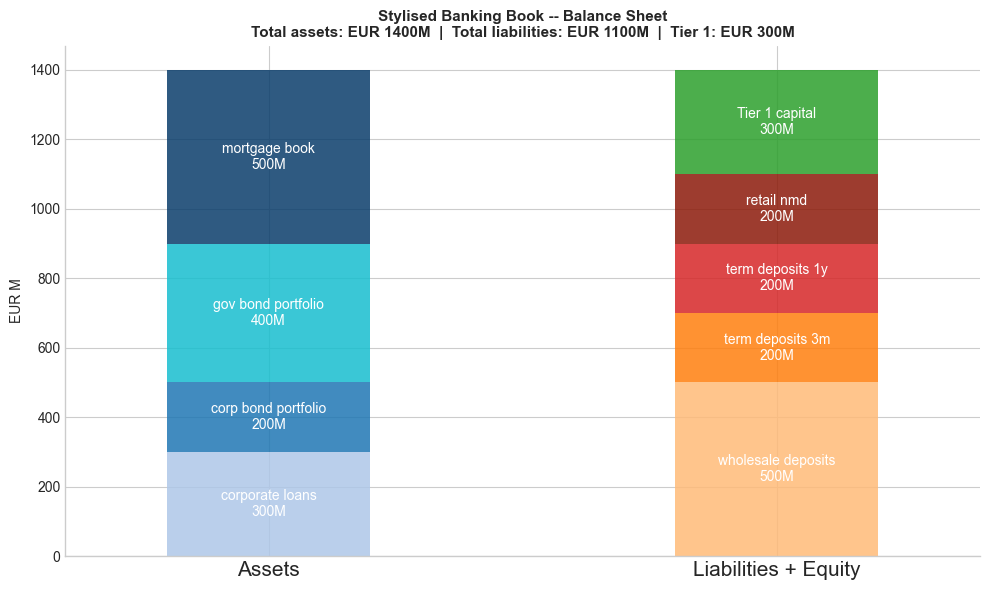

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

# -----------------------------------------------------------------------
# stacked balance sheet -- assets left, liabilities + equity right
# assets: most liquid at top, least liquid at bottom
# liabilities: most short term at top, least short term at bottom
# -----------------------------------------------------------------------

# order assets most liquid to least liquid (top to bottom = stack bottom to top)
asset_order = [
    "corporate_loans",
    "corp_bond_portfolio",
    "gov_bond_portfolio",
    "mortgage_book",
]

# order liabilities most short term to least short term
liab_order = [
    "wholesale_deposits",
    "term_deposits_3m",
    "term_deposits_1y",
    "retail_nmd",
]

asset_colors = ["#aec7e8", "#1f77b4", "#17becf", "#0a3d6b"]
liab_colors  = ["#ffbb78", "#ff7f0e", "#d62728", "#8c1a0a"]
equity_color = "#2ca02c"

# plot assets -- stacked horizontal bars on left side (negative x)
bottom = 0
for i, name in enumerate(asset_order):
    val = book[name]["notional"]
    ax.bar(0, val, bottom=bottom, width=0.4,
           color=asset_colors[i], alpha=0.85,
           label=name.replace("_", " "))
    ax.text(0, bottom + val/2,
            f"{name.replace('_', ' ')}\n{val}M",
            ha="center", va="center", fontsize=10,
            color="white", fontweight="500")
    bottom += val

# plot liabilities -- stacked on right
bottom = 0
for i, name in enumerate(liab_order):
    val = book[name]["notional"]
    ax.bar(1, val, bottom=bottom, width=0.4,
           color=liab_colors[i], alpha=0.85)
    ax.text(1, bottom + val/2,
            f"{name.replace('_', ' ')}\n{val}M",
            ha="center", va="center", fontsize=10,
            color="white", fontweight="500")
    bottom += val

# plot equity on top of liabilities
ax.bar(1, tier1_capital, bottom=bottom, width=0.4,
       color=equity_color, alpha=0.85)
ax.text(1, bottom + tier1_capital/2,
        f"Tier 1 capital\n{tier1_capital}M",
        ha="center", va="center", fontsize=10,
        color="white", fontweight="500")

# formatting
total_assets = sum(book[k]["notional"] for k in asset_order)
total_liabs  = sum(book[k]["notional"] for k in liab_order)

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(0, max(total_assets, total_liabs + tier1_capital) * 1.05)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Assets", "Liabilities + Equity"], fontsize=15)
ax.set_ylabel("EUR M")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title(
    f"Stylised Banking Book -- Balance Sheet\n"
    f"Total assets: EUR {total_assets}M  |  "
    f"Total liabilities: EUR {total_liabs}M  |  "
    f"Tier 1: EUR {tier1_capital}M",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()

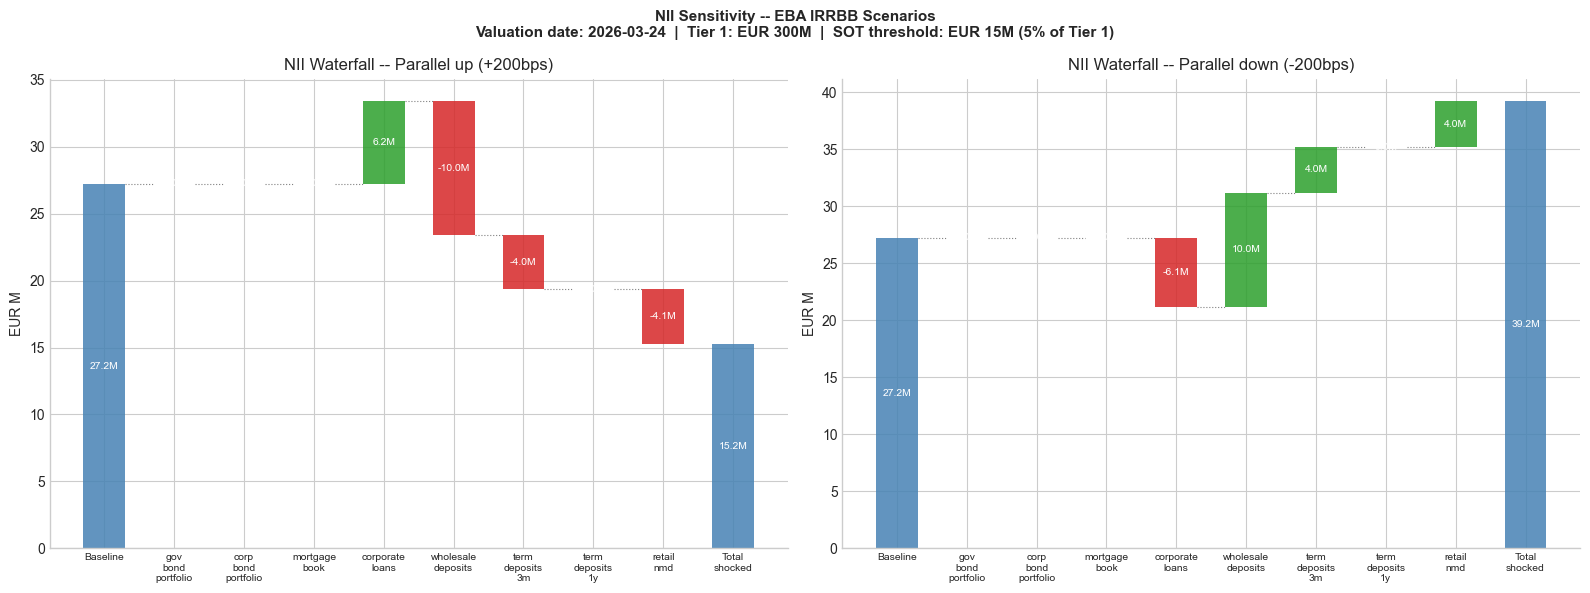

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def waterfall(ax, breakdown_base, breakdown_shocked, title, shock_label):
    """
    Waterfall chart showing NII baseline and delta contribution per position.
    """
    positions  = list(breakdown_base.keys())
    labels     = ["Baseline"] + [p.replace("_", "\n") for p in positions] + ["Total\nshocked"]

    # compute deltas
    deltas = {p: breakdown_shocked[p] - breakdown_base[p] for p in positions}
    total_base    = sum(breakdown_base.values())
    total_shocked = sum(breakdown_shocked.values())

    # running total for waterfall
    values  = [total_base] + [deltas[p] for p in positions] + [total_shocked]
    bottoms = []
    running = total_base

    # baseline bar starts at 0
    bottoms.append(0)

    # delta bars start at running total
    for p in positions:
        d = deltas[p]
        if d >= 0:
            bottoms.append(running)
        else:
            bottoms.append(running + d)
        running += d

    # final bar starts at 0
    bottoms.append(0)

    # colors
    colors = []
    colors.append("steelblue")  # baseline
    for p in positions:
        colors.append("#2ca02c" if deltas[p] >= 0 else "#d62728")
    colors.append("steelblue" if total_shocked >= 0 else "#d62728")  # total

    bars = ax.bar(range(len(labels)), [abs(v) for v in values],
                  bottom=bottoms, color=colors, alpha=0.85, width=0.6)

    # value labels
    for i, (val, bot) in enumerate(zip(values, bottoms)):
        y = bot + abs(val)/2
        ax.text(i, y, f"{val:.1f}M",
                ha="center", va="center", fontsize=7.5,
                color="white", fontweight="500")

    # connector lines between bars
    running = total_base
    for i, p in enumerate(positions):
        d = deltas[p]
        x_left  = i + 0.3
        x_right = i + 0.7
        y_level = running if d >= 0 else running + d
        ax.plot([x_left, x_right], [running, running],
                color="grey", linewidth=0.8, linestyle=":")
        running += d

    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylabel("EUR M")
    ax.set_title(f"NII Waterfall -- {shock_label}", fontweight="500")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

waterfall(axes[0], breakdown_base, breakdown_up,
          "Parallel Up", f"Parallel up (+{EBA_SHOCKS['EUR']['parallel']}bps)")
waterfall(axes[1], breakdown_base, breakdown_down,
          "Parallel Down", f"Parallel down (-{EBA_SHOCKS['EUR']['parallel']}bps)")

fig.suptitle(
    f"NII Sensitivity -- EBA IRRBB Scenarios\n"
    f"Valuation date: {valuation_date}  |  Tier 1: EUR {tier1_capital}M  |  "
    f"SOT threshold: EUR {tier1_capital * 0.05:.0f}M (5% of Tier 1)",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()

## 4. Repricing Gap Analysis

The repricing gap is the net difference between assets and liabilities
repricing in each maturity bucket. A positive gap means more assets than
liabilities reprice in that period -- the bank benefits from rate rises
but suffers from rate falls. A negative gap is the opposite.

$$Gap_i = \sum_{assets} CF_i^{assets} - \sum_{liabilities} CF_i^{liabilities}$$

Under EBA/RTS/2022/09 cash flows are slotted into 19 prescribed time
buckets from overnight to beyond 20 years. The repricing cash flow for
each instrument is the notional amount that reprices at the bucket date --
either because the instrument matures (fixed rate) or because it resets
(floating rate). Each position appears once, in the bucket corresponding
to its next repricing date.

**Treatment of equity under EBA/RTS/2022/09:**

Equity has no contractual maturity -- it is permanent capital. The EBA
standardised approach requires equity to be slotted as a liability in the
longest bucket (>20Y). This ensures the sum of all gaps across all 19
buckets equals zero, preserving balance sheet consistency:

$$\sum_{i=1}^{19} Gap_i = 0$$

Without this treatment the cumulative gap would end at Tier 1 capital
rather than zero, overstating the structural asset sensitivity of the book.

The cumulative gap shows the bank's structural duration position --
a persistently negative cumulative gap signals a liability-sensitive
book that benefits from falling rates and suffers from rising rates.
The cumulative gap returning to zero at the >20Y bucket confirms
balance sheet integrity.

In [58]:
# -----------------------------------------------------------------------
# EBA prescribed 19 maturity buckets (mid-points in years)
# -----------------------------------------------------------------------
EBA_BUCKETS = {
    "ON"        : (0,        1/365),
    ">1D-1M"    : (1/365,    1/12),
    ">1M-3M"    : (1/12,     3/12),
    ">3M-6M"    : (3/12,     6/12),
    ">6M-9M"    : (6/12,     9/12),
    ">9M-1Y"    : (9/12,     1.0),
    ">1Y-1.5Y"  : (1.0,      1.5),
    ">1.5Y-2Y"  : (1.5,      2.0),
    ">2Y-3Y"    : (2.0,      3.0),
    ">3Y-4Y"    : (3.0,      4.0),
    ">4Y-5Y"    : (4.0,      5.0),
    ">5Y-6Y"    : (5.0,      6.0),
    ">6Y-7Y"    : (6.0,      7.0),
    ">7Y-8Y"    : (7.0,      8.0),
    ">8Y-9Y"    : (8.0,      9.0),
    ">9Y-10Y"   : (9.0,      10.0),
    ">10Y-15Y"  : (10.0,     15.0),
    ">15Y-20Y"  : (15.0,     20.0),
    ">20Y"      : (20.0,     50.0),
}

def slot_to_bucket(maturity_years):
    """Return the EBA bucket label for a given maturity in years."""
    for label, (low, high) in EBA_BUCKETS.items():
        if low <= maturity_years < high:
            return label
    return ">20Y"

# -----------------------------------------------------------------------
# slot all repricing cash flows into buckets
# -----------------------------------------------------------------------
bucket_labels = list(EBA_BUCKETS.keys())
gap = pd.DataFrame(0.0, index=bucket_labels,
                   columns=["assets", "liabilities", "gap"])

for name, pos in book.items():
    notional        = pos["notional"]
    maturity_months = pos["maturity_months"]
    is_floating     = pos["floating"]
    position_type   = pos["type"]

    if is_floating:
        # floating -- slots only at NEXT repricing date
        # not all future rollovers -- constant balance sheet
        # assumes the position is rolled but only the first
        # repricing event matters for the gap
        t_years = maturity_months / 12
        bucket  = slot_to_bucket(t_years)
        if position_type == "asset":
            gap.loc[bucket, "assets"] += notional
        else:
            gap.loc[bucket, "liabilities"] += notional
    else:
        # fixed rate -- reprices only at final maturity
        t_years = maturity_months / 12
        bucket  = slot_to_bucket(t_years)
        if position_type == "asset":
            gap.loc[bucket, "assets"] += notional
        else:
            gap.loc[bucket, "liabilities"] += notional

# equity has no maturity -- slot as liability in longest bucket
gap.loc[">20Y", "liabilities"] += tier1_capital
gap["gap"]            = gap["assets"] - gap["liabilities"]
gap["cumulative_gap"] = gap["gap"].cumsum()

print(f"Sum of all gaps: {gap['gap'].sum():.1f}M (should be 0)")
print(f"Final cumulative gap: {gap['cumulative_gap'].iloc[-1]:.1f}M (should be 0)")


print("Repricing gap per EBA maturity bucket (EUR M)")
print(f"\n{'Bucket':<15} {'Assets':>10} {'Liabilities':>13} {'Gap':>10} {'Cum Gap':>10}")
print("-" * 62)
for label in bucket_labels:
    row = gap.loc[label]
    if row["assets"] != 0 or row["liabilities"] != 0:
        print(f"{label:<15} {row['assets']:>10.1f} {row['liabilities']:>13.1f} "
              f"{row['gap']:>10.1f} {row['cumulative_gap']:>10.1f}")

Sum of all gaps: 0.0M (should be 0)
Final cumulative gap: 0.0M (should be 0)
Repricing gap per EBA maturity bucket (EUR M)

Bucket              Assets   Liabilities        Gap    Cum Gap
--------------------------------------------------------------
>1M-3M                 0.0         500.0     -500.0     -500.0
>3M-6M                 0.0         200.0     -200.0     -700.0
>1Y-1.5Y               0.0         200.0     -200.0     -900.0
>2Y-3Y                 0.0         200.0     -200.0    -1100.0
>3Y-4Y               300.0           0.0      300.0     -800.0
>5Y-6Y               200.0           0.0      200.0     -600.0
>10Y-15Y             400.0           0.0      400.0     -200.0
>20Y                 500.0         300.0      200.0        0.0


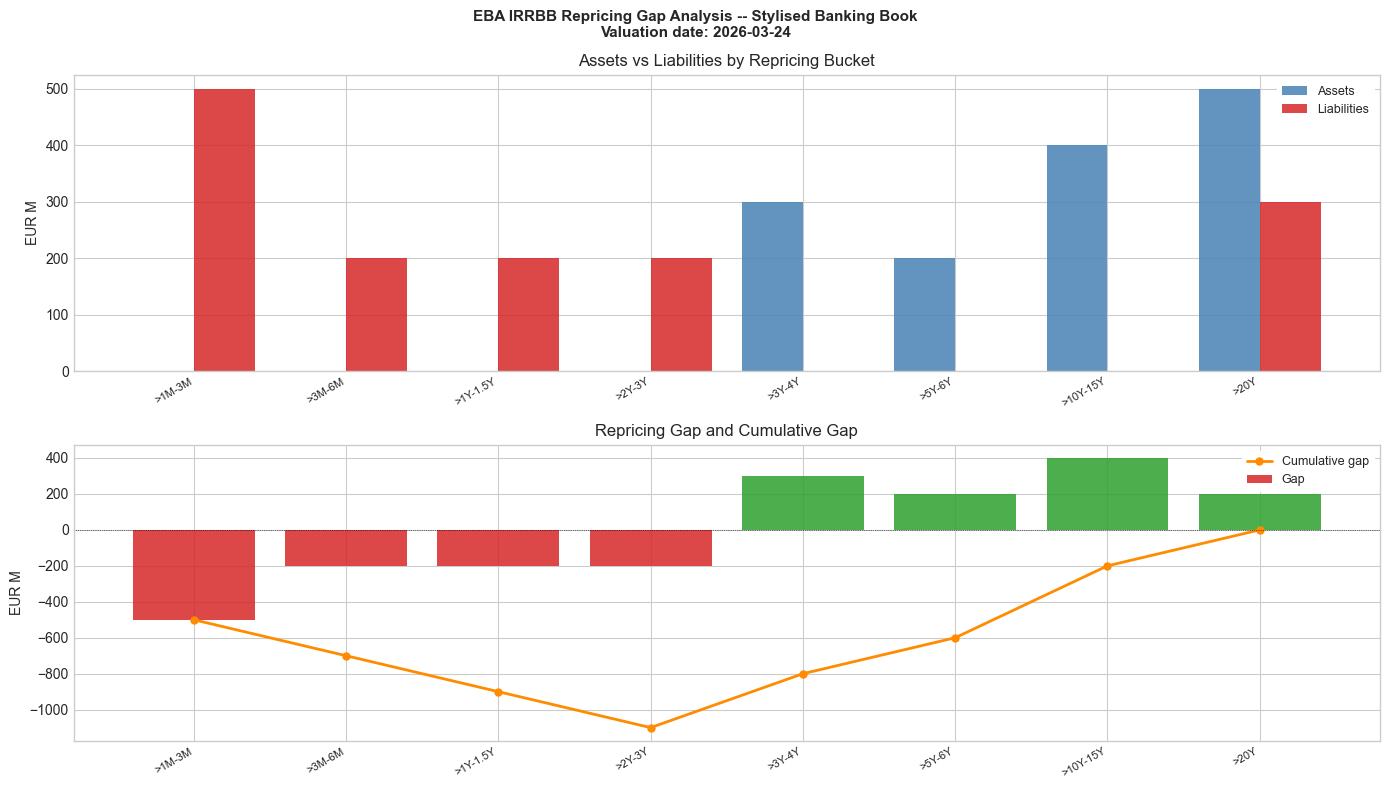

In [59]:
 # -----------------------------------------------------------------------
# plot repricing gap
# -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# filter only buckets with activity
active = gap[(gap["assets"] != 0) | (gap["liabilities"] != 0)].copy()
x      = np.arange(len(active))

# panel 1 -- assets vs liabilities per bucket
axes[0].bar(x - 0.2, active["assets"], width=0.4,
            color="steelblue", alpha=0.85, label="Assets")
axes[0].bar(x + 0.2, active["liabilities"], width=0.4,
            color="#d62728", alpha=0.85, label="Liabilities")
axes[0].set_xticks(x)
axes[0].set_xticklabels(active.index, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("EUR M")
axes[0].set_title("Assets vs Liabilities by Repricing Bucket")
axes[0].legend(frameon=True, facecolor="white", framealpha=1,
               edgecolor="white", fontsize=9)
axes[0].axhline(0, color="black", linewidth=0.5)

# panel 2 -- gap and cumulative gap
colors_gap = ["#2ca02c" if v >= 0 else "#d62728" for v in active["gap"]]
axes[1].bar(x, active["gap"], color=colors_gap, alpha=0.85, label="Gap")
axes[1].plot(x, active["cumulative_gap"], color="darkorange",
             linewidth=2, marker="o", markersize=5, label="Cumulative gap")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle=":")
axes[1].set_xticks(x)
axes[1].set_xticklabels(active.index, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("EUR M")
axes[1].set_title("Repricing Gap and Cumulative Gap")
axes[1].legend(frameon=True, facecolor="white", framealpha=1,
               edgecolor="white", fontsize=9)

fig.suptitle(
    f"EBA IRRBB Repricing Gap Analysis -- Stylised Banking Book\n"
    f"Valuation date: {valuation_date}",
    fontsize=11, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [62]:
# -----------------------------------------------------------------------
# IRRBB SOT Summary Dashboard
# -----------------------------------------------------------------------

# EVE SOT -- worst scenario across all six
eve_scenario_cols = ["parallel_up", "parallel_down", "steepener",
                     "flattener", "short_up", "short_down"]

# total delta EVE per scenario (sum across all maturities, scaled to book size)
# here we use EUR 1M notional -- in practice scale to actual book notional
eve_sot = {}
for sc in eve_scenario_cols:
    total_delta = eve_table[sc].sum()
    eve_sot[sc] = total_delta

worst_eve_scenario = min(eve_sot, key=lambda x: eve_sot[x])
worst_eve_value    = eve_sot[worst_eve_scenario]

# NII SOT -- parallel up and down only
nii_sot = {
    "parallel_up"   : delta_nii_up,
    "parallel_down" : delta_nii_down,
}
worst_nii_scenario = min(nii_sot, key=lambda x: abs(nii_sot[x]) * -1
                         if nii_sot[x] < 0 else abs(nii_sot[x]))
worst_nii_value    = nii_sot[worst_nii_scenario]

# SOT ratios -- note EVE is per 1M notional, NII is for full book
# for illustration we use the same Tier 1 for both
eve_sot_ratio = abs(worst_eve_value) / (tier1_capital * 1_000_000) * 100
nii_sot_ratio = abs(worst_nii_value) / tier1_capital * 100

print("=" * 60)
print("IRRBB SUPERVISORY OUTLIER TEST -- SUMMARY")
print(f"Valuation date : {valuation_date}")
print(f"Tier 1 capital : EUR {tier1_capital}M")
print("=" * 60)

print(f"\n{'EVE SOT':}")
print(f"  Reference    : EBA/RTS/2022/10 Article 3")
print(f"  Threshold    : 15% of Tier 1 capital")
print(f"  Worst scenario: {worst_eve_scenario.replace('_', ' ').title()}")
print(f"  Delta EVE    : EUR {worst_eve_value:,.0f} per 1M notional")
print(f"  Note         : Scale to actual book notional for SOT ratio")

print(f"\n{'NII SOT':}")
print(f"  Reference    : EBA/RTS/2022/10 Article 6")
print(f"  Threshold    : 5% of Tier 1 capital = EUR {tier1_capital * 0.05:.1f}M")
print(f"  Worst scenario: {worst_nii_scenario.replace('_', ' ').title()}")
print(f"  Delta NII    : EUR {worst_nii_value:.2f}M")
print(f"  SOT ratio    : {nii_sot_ratio:.2f}%")
print(f"  Result       : {'*** BREACH ***' if nii_sot_ratio > 5 else 'OK -- within threshold'}")

print(f"\n{'─' * 60}")
print(f"  Note: EVE SOT ratio requires scaling delta EVE to the")
print(f"  actual banking book notional. With a EUR {tier1_capital}M Tier 1")
print(f"  the EVE limit is EUR {tier1_capital * 0.15:.0f}M absolute decline.")
print(f"{'=' * 60}")

IRRBB SUPERVISORY OUTLIER TEST -- SUMMARY
Valuation date : 2026-03-24
Tier 1 capital : EUR 300M

EVE SOT
  Reference    : EBA/RTS/2022/10 Article 3
  Threshold    : 15% of Tier 1 capital
  Worst scenario: Parallel Up
  Delta EVE    : EUR -536,911 per 1M notional
  Note         : Scale to actual book notional for SOT ratio

NII SOT
  Reference    : EBA/RTS/2022/10 Article 6
  Threshold    : 5% of Tier 1 capital = EUR 15.0M
  Worst scenario: Parallel Up
  Delta NII    : EUR -11.99M
  SOT ratio    : 4.00%
  Result       : OK -- within threshold

────────────────────────────────────────────────────────────
  Note: EVE SOT ratio requires scaling delta EVE to the
  actual banking book notional. With a EUR 300M Tier 1
  the EVE limit is EUR 45M absolute decline.
